# Stage 2: Shortcut Auditing — Probing & SHAP Attribution

**Focus:** The 6 MI-flagged gender shortcut candidates from Stage 1 (18-feature analysis):

| Feature | Gender Assoc. | I(f;gender) | MI Drop |
|---|---|---|---|
| `fp_singular` | Feminine-coded | 0.0310 | 37.5 % |
| `emotional_feeling` | Feminine-coded | 0.0167 | 33.8 % |
| `excl_intensifiers` | Feminine-coded | 0.0138 | 47.6 % |
| `hedge_density` | Feminine-coded | 0.0135 | 28.6 % |
| `post_length` | Feminine-coded | 0.0141 | 28.3 % |
| `question_density` | Feminine-coded | 0.0106 | 29.5 % |

**Controls (4):** `absolutist`, `past_tense`, `negation`, `cognitive_processing` — used for comparison probing.

**Analyses:**
1. **Probing classifiers** — Can a linear probe on frozen DistilRoBERTa-base [CLS] embeddings recover the shortcut feature? If yes → the model *encodes* gender-correlated information.
2. **SHAP token attribution** — Which tokens drive the mental-health prediction? Measure how much SHAP mass concentrates on shortcut-associated tokens.
3. **Feature ablation** — Zero-out each shortcut feature and measure AUC degradation → quantifies reliance.

**Data:** 32,200 LIWC-annotated posts (`features_18_extracted.pkl`) from Stage 1

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, r2_score)
from transformers import AutoTokenizer, AutoModel
from datasets import Dataset

sns.set_style('whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}")

# ── The 6 MI-flagged shortcut candidates (18-feature analysis) ────────────────
SHORTCUT_FEATURES = [
    'fp_singular', 'emotional_feeling', 'excl_intensifiers',
    'hedge_density', 'post_length', 'question_density',
]
SHORTCUT_META = {
    'fp_singular':       {'gender': 'Feminine-coded', 'mi_drop': 37.5},
    'emotional_feeling': {'gender': 'Feminine-coded', 'mi_drop': 33.8},
    'excl_intensifiers': {'gender': 'Feminine-coded', 'mi_drop': 47.6},
    'hedge_density':     {'gender': 'Feminine-coded', 'mi_drop': 28.6},
    'post_length':       {'gender': 'Feminine-coded', 'mi_drop': 28.3},
    'question_density':  {'gender': 'Feminine-coded', 'mi_drop': 29.5},
}
CONTROL_FEATURES = ['absolutist', 'past_tense', 'negation', 'cognitive_processing']

print(f"Auditing {len(SHORTCUT_FEATURES)} shortcut candidates: {SHORTCUT_FEATURES}")
print(f"Controls ({len(CONTROL_FEATURES)}): {CONTROL_FEATURES}")

Device: cuda  |  GPUs: 4
Auditing 6 shortcut candidates: ['fp_singular', 'emotional_feeling', 'excl_intensifiers', 'hedge_density', 'post_length', 'question_density']
Controls (4): ['absolutist', 'past_tense', 'negation', 'cognitive_processing']


In [2]:
# ── Load Stage 1 data (18 features: 14 candidates + 4 controls) ──────────────
df = pd.read_pickle('data/stage1/features_18_extracted.pkl')
df['text'] = df['text'].fillna('')
GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'

print(f"Loaded {len(df):,} rows")
print(f"Label dist: {df['binary_label'].value_counts().to_dict()}")
print(f"Gender dist: {df[GENDER_COL].value_counts().to_dict()}")

# Quick sanity — shortcut features present
for f in SHORTCUT_FEATURES:
    print(f"  {f}: mean={df[f].mean():.4f}, std={df[f].std():.4f}")

# Restrict MI analyses to male/female
mf_mask = df[GENDER_COL].isin(['male', 'female'])
df_mf = df[mf_mask].copy()
df_mf['gender_bin'] = (df_mf[GENDER_COL] == 'female').astype(int)
print(f"\nMale/female subset: {len(df_mf):,} rows")

Loaded 32,200 rows
Label dist: {0: 22601, 1: 9599}
Gender dist: {'female': 16100, 'male': 16100}
  fp_singular: mean=0.0551, std=0.0418
  emotional_feeling: mean=0.0056, std=0.0109
  excl_intensifiers: mean=0.0135, std=0.0194
  hedge_density: mean=0.0252, std=0.0240
  post_length: mean=150.1974, std=212.5046
  question_density: mean=0.1039, std=0.1926

Male/female subset: 32,200 rows


## 2A — Probing Classifiers on Frozen DistilRoBERTa Embeddings

**Question:** Does DistilRoBERTa's `[CLS]` representation encode the 6 shortcut features and 4 control features?

**Method:** Extract `[CLS]` embeddings from frozen `distilroberta-base` (no fine-tuning). Train a linear probe to predict:
1. Each shortcut feature value (regression → R²) — 6 shortcuts + 4 controls
2. The binarised shortcut feature (above/below median → AUC)
3. Gender (male/female → AUC)
4. Mental-health label (binary_label → AUC)

If the probe can recover shortcut features from `[CLS]`, the model *encodes* gender-correlated stylistic information even before task fine-tuning. The controls provide a baseline for comparison.

In [4]:
# ── Extract [CLS] embeddings from frozen DistilRoBERTa ────────────────────────
MODEL_NAME = 'distilroberta-base'
MAX_LEN = 256
BATCH_SIZE = 128  # inference only — fits easily on V100

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder   = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

def extract_cls_embeddings(texts, batch_size=BATCH_SIZE):
    """Extract [CLS] (first token) embeddings in batches."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True,
                        max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = encoder(**enc)
        # [CLS] is token 0
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embs.append(cls_emb)
        if (i // batch_size) % 20 == 0:
            print(f"  Batch {i//batch_size + 1}/{(len(texts)-1)//batch_size + 1}", end='\r')
    print()
    return np.vstack(all_embs)

print(f"Extracting [CLS] embeddings for {len(df):,} posts …")
X_cls = extract_cls_embeddings(df['text'].tolist())
print(f"Embedding shape: {X_cls.shape}  (768-d per post)")

# Cache for Stage 3
os.makedirs('data/stage2', exist_ok=True)
np.save('data/stage2/cls_embeddings.npy', X_cls)
print(f"Saved → data/stage2/cls_embeddings.npy")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 174.88it/s]
RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting [CLS] embeddings for 32,200 posts …
  Batch 241/252
Embedding shape: (32200, 768)  (768-d per post)
Saved → data/stage2/cls_embeddings.npy


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# PROBE 1 — Can [CLS] embeddings predict shortcut/control feature values?
# ══════════════════════════════════════════════════════════════════════════════
# (a) Regression probe: predict continuous feature value → R²
# (b) Classification probe: predict above/below median → AUC

scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

probe_results = []
PROBE_FEATURES = SHORTCUT_FEATURES + CONTROL_FEATURES  # 6 shortcuts + 4 controls

for feat in PROBE_FEATURES:
    y_cont = df[feat].fillna(0).values.astype(float)
    role = 'shortcut' if feat in SHORTCUT_FEATURES else 'control'

    # (a) Regression — Ridge on [CLS] → feature value
    ridge = Ridge(alpha=1.0)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Use binary_label for stratification (keeps folds balanced on outcome)
    y_strat = df['binary_label'].values
    r2_scores = []
    for train_idx, test_idx in cv.split(X_cls_scaled, y_strat):
        ridge.fit(X_cls_scaled[train_idx], y_cont[train_idx])
        y_hat = ridge.predict(X_cls_scaled[test_idx])
        r2_scores.append(r2_score(y_cont[test_idx], y_hat))
    r2_mean = np.mean(r2_scores)

    # (b) Classification — above/below median
    median_val = np.median(y_cont)
    y_bin = (y_cont > median_val).astype(int)
    clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = cross_val_score(clf, X_cls_scaled, y_bin, cv=cv_cls, scoring='roc_auc')

    probe_results.append({
        'feature': feat,
        'role': role,
        'probe_R2': r2_mean,
        'probe_AUC_median_split': aucs.mean(),
        'probe_AUC_std': aucs.std(),
    })
    print(f"  [{role:8s}] {feat:22s}  R²={r2_mean:.4f}  AUC(med-split)={aucs.mean():.3f}±{aucs.std():.3f}")

# ── PROBE 2 — Can [CLS] predict gender? ──────────────────────────────────────
mf_idx = df.index[mf_mask].tolist()
X_mf = X_cls_scaled[mf_idx]
y_gender = df_mf['gender_bin'].values

clf_g = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
cv_g = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs_g = cross_val_score(clf_g, X_mf, y_gender, cv=cv_g, scoring='roc_auc')
print(f"\n  {'gender (m/f)':22s}  AUC={aucs_g.mean():.3f}±{aucs_g.std():.3f}")

# ── PROBE 3 — Can [CLS] predict mental-health label? ─────────────────────────
y_label = df['binary_label'].values
clf_l = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
cv_l = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs_l = cross_val_score(clf_l, X_cls_scaled, y_label, cv=cv_l, scoring='roc_auc')
print(f"  {'binary_label':22s}  AUC={aucs_l.mean():.3f}±{aucs_l.std():.3f}")

probe_df = pd.DataFrame(probe_results)
probe_df

  [shortcut] fp_singular             R²=0.8555  AUC(med-split)=0.976±0.002
  [shortcut] emotional_feeling       R²=0.3778  AUC(med-split)=0.904±0.002
  [shortcut] excl_intensifiers       R²=0.5957  AUC(med-split)=0.882±0.002
  [shortcut] hedge_density           R²=0.4060  AUC(med-split)=0.832±0.004
  [shortcut] post_length             R²=0.4412  AUC(med-split)=0.998±0.000
  [shortcut] question_density        R²=0.7765  AUC(med-split)=0.979±0.001
  [control ] absolutist              R²=0.3032  AUC(med-split)=0.891±0.002
  [control ] past_tense              R²=0.6664  AUC(med-split)=0.938±0.003
  [control ] negation                R²=0.5404  AUC(med-split)=0.905±0.003
  [control ] cognitive_processing    R²=0.2743  AUC(med-split)=0.894±0.003

  gender (m/f)            AUC=0.959±0.001
  binary_label            AUC=0.798±0.005


,feature,role,probe_R2,probe_AUC_median_split,probe_AUC_std
0,fp_singular,shortcut,0.855490,0.976069,0.001530
1,emotional_feeling,shortcut,0.377769,0.903603,0.002451
2,excl_intensifiers,shortcut,0.595720,0.881697,0.002415
3,hedge_density,shortcut,0.406042,0.831567,0.004263
4,post_length,shortcut,0.441211,0.997557,0.000138
5,question_density,shortcut,0.776499,0.978979,0.001008
6,absolutist,control,0.303203,0.891016,0.002122
7,past_tense,control,0.666358,0.938473,0.002570
8,negation,control,0.540352,0.904768,0.002734
9,cognitive_processing,control,0.274339,0.893843,0.003207


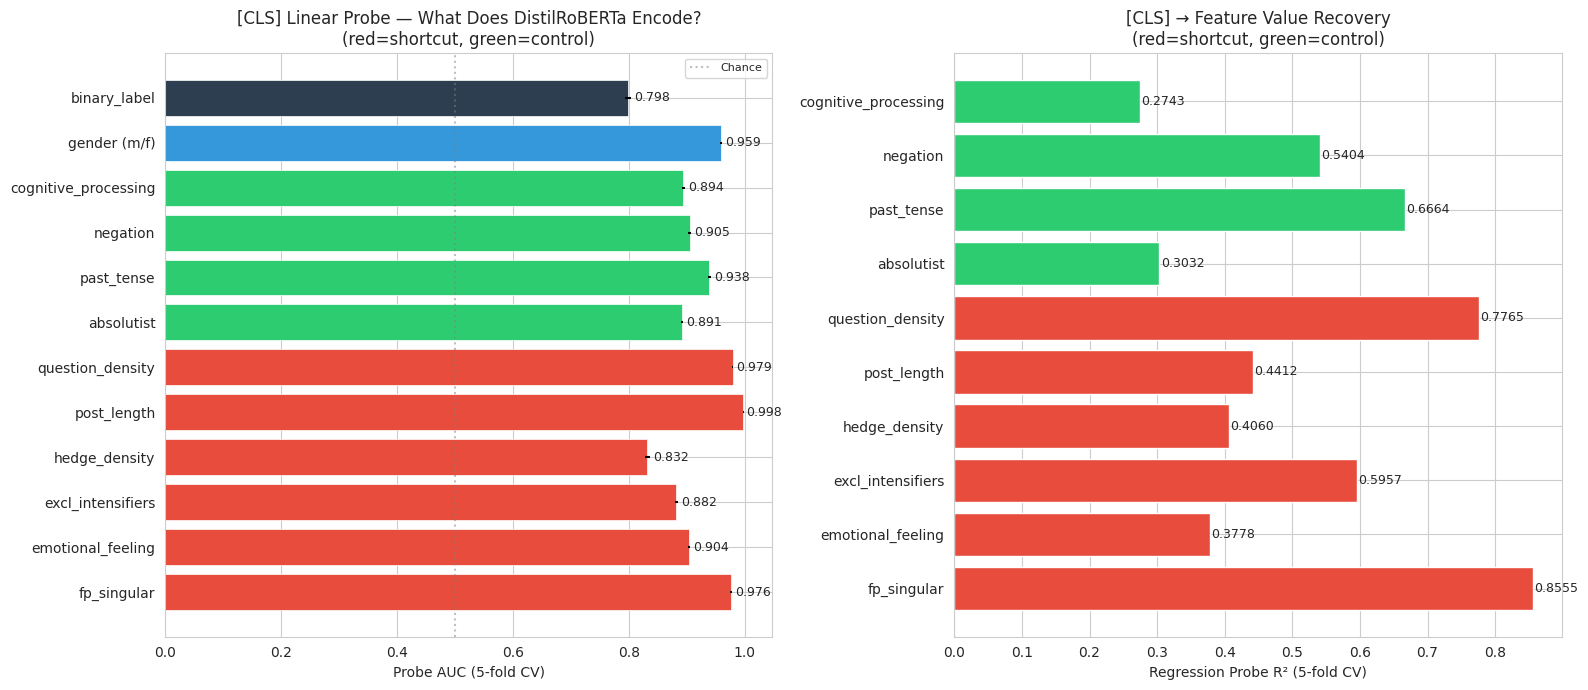

Saved → data/stage2/probing_results.png


In [5]:
# ── Probing visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (A) Probe AUC: shortcut + control features + gender + label
probe_labels = PROBE_FEATURES + ['gender (m/f)', 'binary_label']
probe_aucs   = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_median_split'].values[0]
                for f in PROBE_FEATURES] + [aucs_g.mean(), aucs_l.mean()]
probe_stds   = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_std'].values[0]
                for f in PROBE_FEATURES] + [aucs_g.std(), aucs_l.std()]
# Colors: red = shortcut, green = control, blue = gender, dark = label
colors = (['#e74c3c'] * len(SHORTCUT_FEATURES) +
          ['#2ecc71'] * len(CONTROL_FEATURES) +
          ['#3498db', '#2c3e50'])

bars = axes[0].barh(range(len(probe_labels)), probe_aucs, xerr=probe_stds,
                     color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(probe_labels)))
axes[0].set_yticklabels(probe_labels, fontsize=10)
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Chance')
axes[0].set_xlabel('Probe AUC (5-fold CV)')
axes[0].set_title('[CLS] Linear Probe — What Does DistilRoBERTa Encode?\n(red=shortcut, green=control)')
axes[0].legend(fontsize=8)
for i, (auc, std) in enumerate(zip(probe_aucs, probe_stds)):
    axes[0].text(auc + std + 0.005, i, f'{auc:.3f}', va='center', fontsize=9)

# (B) Regression R² for continuous feature recovery
r2_vals = probe_df['probe_R2'].values
r2_colors = (['#e74c3c'] * len(SHORTCUT_FEATURES) +
             ['#2ecc71'] * len(CONTROL_FEATURES))
axes[1].barh(range(len(PROBE_FEATURES)), r2_vals, color=r2_colors, edgecolor='white')
axes[1].set_yticks(range(len(PROBE_FEATURES)))
axes[1].set_yticklabels(PROBE_FEATURES, fontsize=10)
axes[1].axvline(0, color='grey', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Regression Probe R² (5-fold CV)')
axes[1].set_title('[CLS] → Feature Value Recovery\n(red=shortcut, green=control)')
for i, r2 in enumerate(r2_vals):
    axes[1].text(max(r2, 0) + 0.002, i, f'{r2:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/stage2/probing_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/probing_results.png")

## 2A′ — Layer-wise Probing: Feature Representation as a Function of Model Depth

**Question:** At which transformer layer do shortcut features, controls, gender, and the label become linearly separable?

**Method:** DistilRoBERTa has **6 transformer layers** (+ an initial embedding layer = 7 extraction points). For each layer, extract the `[CLS]` hidden state, then train linear probes (AUC for classification) for:
- Each of the 6 shortcut features (binarised at median)
- Each of the 4 control features
- Gender (male/female)
- Binary mental-health label

**Interpretation:**
- Features that become separable **early** (layers 0–1) are captured by low-level token/position patterns.
- Features that emerge **later** (layers 4–5) require contextual composition.
- If shortcuts track **gender's curve** more closely than the **label's curve**, it reinforces the confounding concern.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# LAYER-WISE [CLS] EXTRACTION — All 6 DistilRoBERTa layers + embedding layer
# ══════════════════════════════════════════════════════════════════════════════
# DistilRoBERTa architecture:
#   Layer 0 = token embeddings (before any transformer block)
#   Layers 1–6 = output of each of the 6 transformer blocks

def extract_cls_all_layers(texts, model, tok, batch_size=128, max_len=256):
    """Extract [CLS] hidden states from every layer (embedding + 6 transformer layers)."""
    n_layers = model.config.num_hidden_layers  # 6 for distilroberta
    # We'll collect n_layers + 1 representations (embedding + each layer output)
    layer_embs = [[] for _ in range(n_layers + 1)]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tok(batch, truncation=True, padding=True,
                  max_length=max_len, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        # out.hidden_states: tuple of (n_layers+1) tensors, each (batch, seq_len, hidden_dim)
        # index 0 = embedding output, index k = output of transformer layer k
        for layer_idx in range(n_layers + 1):
            cls_vec = out.hidden_states[layer_idx][:, 0, :].cpu().numpy()
            layer_embs[layer_idx].append(cls_vec)
        if (i // batch_size) % 25 == 0:
            print(f"  Batch {i // batch_size + 1}/{(len(texts) - 1) // batch_size + 1}", end='\r')

    print()
    return [np.vstack(le) for le in layer_embs]

print(f"Extracting [CLS] from all {encoder.config.num_hidden_layers + 1} layers "
      f"for {len(df):,} posts …")
all_layer_cls = extract_cls_all_layers(df['text'].tolist(), encoder, tokenizer)
print(f"Got {len(all_layer_cls)} layer representations, each shape {all_layer_cls[0].shape}")

Extracting [CLS] from all 7 layers for 32,200 posts …
  Batch 251/252
Got 7 layer representations, each shape (32200, 768)


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# LAYER-WISE PROBING — Probe every layer for shortcuts, controls, gender, label
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler as SS

n_layers = len(all_layer_cls)  # 7 (embedding + 6 transformer layers)
layer_names = ['Emb'] + [f'L{i}' for i in range(1, n_layers)]

PROBE_TARGETS = SHORTCUT_FEATURES + CONTROL_FEATURES  # 6 + 4 = 10 features

# ── Prepare binary targets ────────────────────────────────────────────────────
targets = {}
for feat in PROBE_TARGETS:
    vals = df[feat].fillna(0).values.astype(float)
    targets[feat] = (vals > np.median(vals)).astype(int)

# Gender (male/female only)
mf_idx = np.where(df[GENDER_COL].isin(['male', 'female']).values)[0]
targets['gender'] = (df.iloc[mf_idx][GENDER_COL] == 'female').astype(int).values

# Label
targets['binary_label'] = df['binary_label'].values.astype(int)

# ── Probe at each layer ──────────────────────────────────────────────────────
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for layer_idx in range(n_layers):
    X_layer = all_layer_cls[layer_idx]
    scaler = SS()
    X_scaled = scaler.fit_transform(X_layer)

    for target_name, y in targets.items():
        if target_name == 'gender':
            X_probe = X_scaled[mf_idx]
        else:
            X_probe = X_scaled
        y_probe = y

        clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
        aucs = cross_val_score(clf, X_probe, y_probe, cv=cv, scoring='roc_auc')

        role = ('shortcut' if target_name in SHORTCUT_FEATURES
                else 'control' if target_name in CONTROL_FEATURES
                else 'meta')

        results.append({
            'layer': layer_idx,
            'layer_name': layer_names[layer_idx],
            'target': target_name,
            'role': role,
            'AUC': aucs.mean(),
            'AUC_std': aucs.std(),
        })

    print(f"  Layer {layer_names[layer_idx]:3s} done")

layer_probe_df = pd.DataFrame(results)

# ── Print summary table ──────────────────────────────────────────────────────
print("\nLayer-wise probing AUC (5-fold CV):")
pivot = layer_probe_df.pivot(index='target', columns='layer_name', values='AUC')
pivot = pivot[layer_names]  # order columns
print(pivot.round(3).to_string())

  Layer Emb done
  Layer L1  done
  Layer L2  done
  Layer L3  done
  Layer L4  done
  Layer L5  done
  Layer L6  done

Layer-wise probing AUC (5-fold CV):
layer_name            Emb     L1     L2     L3     L4     L5     L6
target                                                             
absolutist            0.5  0.922  0.928  0.915  0.900  0.892  0.891
binary_label          0.5  0.780  0.786  0.789  0.790  0.789  0.798
cognitive_processing  0.5  0.903  0.915  0.911  0.902  0.896  0.894
emotional_feeling     0.5  0.913  0.919  0.916  0.909  0.904  0.904
excl_intensifiers     0.5  0.907  0.899  0.894  0.880  0.863  0.882
fp_singular           0.5  0.977  0.975  0.974  0.973  0.969  0.976
gender                0.5  0.953  0.946  0.944  0.937  0.934  0.959
hedge_density         0.5  0.863  0.870  0.859  0.839  0.831  0.832
negation              0.5  0.939  0.933  0.922  0.913  0.892  0.905
past_tense            0.5  0.939  0.946  0.943  0.939  0.935  0.938
post_length           0.5  0

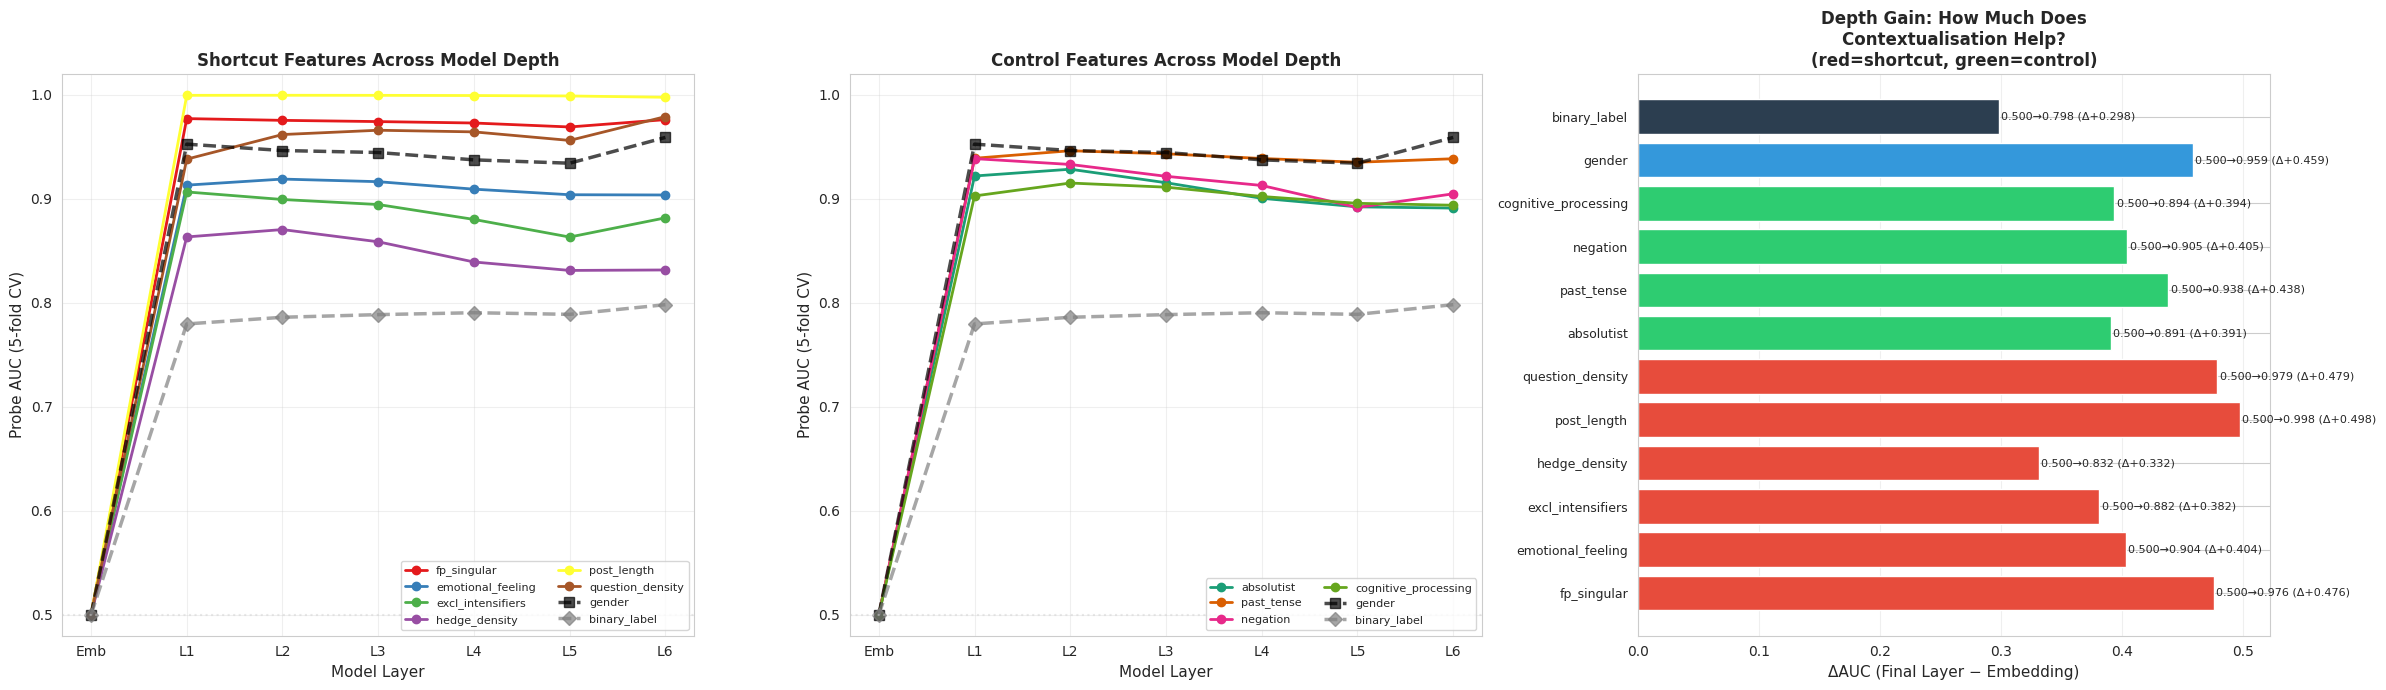

Saved → data/stage2/layerwise_probing.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION — Feature representation as a function of model depth
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

layers_x = np.arange(n_layers)

# ── (A) Shortcut features across layers ───────────────────────────────────────
cmap_sc = plt.cm.Set1(np.linspace(0, 0.7, len(SHORTCUT_FEATURES)))
for i, feat in enumerate(SHORTCUT_FEATURES):
    row = layer_probe_df[layer_probe_df['target'] == feat].sort_values('layer')
    axes[0].plot(layers_x, row['AUC'].values, 'o-', color=cmap_sc[i],
                 label=feat, linewidth=2, markersize=6)
# Add gender & label reference lines
row_g = layer_probe_df[layer_probe_df['target'] == 'gender'].sort_values('layer')
row_l = layer_probe_df[layer_probe_df['target'] == 'binary_label'].sort_values('layer')
axes[0].plot(layers_x, row_g['AUC'].values, 's--', color='black',
             label='gender', linewidth=2.5, markersize=7, alpha=0.7)
axes[0].plot(layers_x, row_l['AUC'].values, 'D--', color='grey',
             label='binary_label', linewidth=2.5, markersize=7, alpha=0.7)
axes[0].axhline(0.5, color='lightgrey', linestyle=':', alpha=0.5)
axes[0].set_xticks(layers_x)
axes[0].set_xticklabels(layer_names, fontsize=10)
axes[0].set_xlabel('Model Layer', fontsize=11)
axes[0].set_ylabel('Probe AUC (5-fold CV)', fontsize=11)
axes[0].set_title('Shortcut Features Across Model Depth', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right', ncol=2)
axes[0].set_ylim(0.48, 1.02)
axes[0].grid(True, alpha=0.3)

# ── (B) Control features across layers ────────────────────────────────────────
cmap_ctrl = plt.cm.Dark2(np.linspace(0, 0.6, len(CONTROL_FEATURES)))
for i, feat in enumerate(CONTROL_FEATURES):
    row = layer_probe_df[layer_probe_df['target'] == feat].sort_values('layer')
    axes[1].plot(layers_x, row['AUC'].values, 'o-', color=cmap_ctrl[i],
                 label=feat, linewidth=2, markersize=6)
axes[1].plot(layers_x, row_g['AUC'].values, 's--', color='black',
             label='gender', linewidth=2.5, markersize=7, alpha=0.7)
axes[1].plot(layers_x, row_l['AUC'].values, 'D--', color='grey',
             label='binary_label', linewidth=2.5, markersize=7, alpha=0.7)
axes[1].axhline(0.5, color='lightgrey', linestyle=':', alpha=0.5)
axes[1].set_xticks(layers_x)
axes[1].set_xticklabels(layer_names, fontsize=10)
axes[1].set_xlabel('Model Layer', fontsize=11)
axes[1].set_ylabel('Probe AUC (5-fold CV)', fontsize=11)
axes[1].set_title('Control Features Across Model Depth', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right', ncol=2)
axes[1].set_ylim(0.48, 1.02)
axes[1].grid(True, alpha=0.3)

# ── (C) AUC gain from Emb → final layer (Δ summary) ─────────────────────────
all_targets_ordered = SHORTCUT_FEATURES + CONTROL_FEATURES + ['gender', 'binary_label']
deltas = []
auc_emb = []
auc_final = []
for t in all_targets_ordered:
    row = layer_probe_df[layer_probe_df['target'] == t].sort_values('layer')
    a_emb = row['AUC'].values[0]
    a_fin = row['AUC'].values[-1]
    deltas.append(a_fin - a_emb)
    auc_emb.append(a_emb)
    auc_final.append(a_fin)

bar_colors = (['#e74c3c'] * len(SHORTCUT_FEATURES) +
              ['#2ecc71'] * len(CONTROL_FEATURES) +
              ['#3498db', '#2c3e50'])
axes[2].barh(range(len(all_targets_ordered)), deltas, color=bar_colors, edgecolor='white')
axes[2].set_yticks(range(len(all_targets_ordered)))
axes[2].set_yticklabels(all_targets_ordered, fontsize=9)
axes[2].axvline(0, color='grey', linewidth=0.5)
axes[2].set_xlabel('ΔAUC (Final Layer − Embedding)', fontsize=11)
axes[2].set_title('Depth Gain: How Much Does\nContextualisation Help?\n'
                   '(red=shortcut, green=control)', fontsize=12, fontweight='bold')
for i, (d, ae, af) in enumerate(zip(deltas, auc_emb, auc_final)):
    axes[2].text(max(d, 0) + 0.002, i, f'{ae:.3f}→{af:.3f} (Δ{d:+.3f})',
                 va='center', fontsize=8)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('data/stage2/layerwise_probing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/layerwise_probing.png")

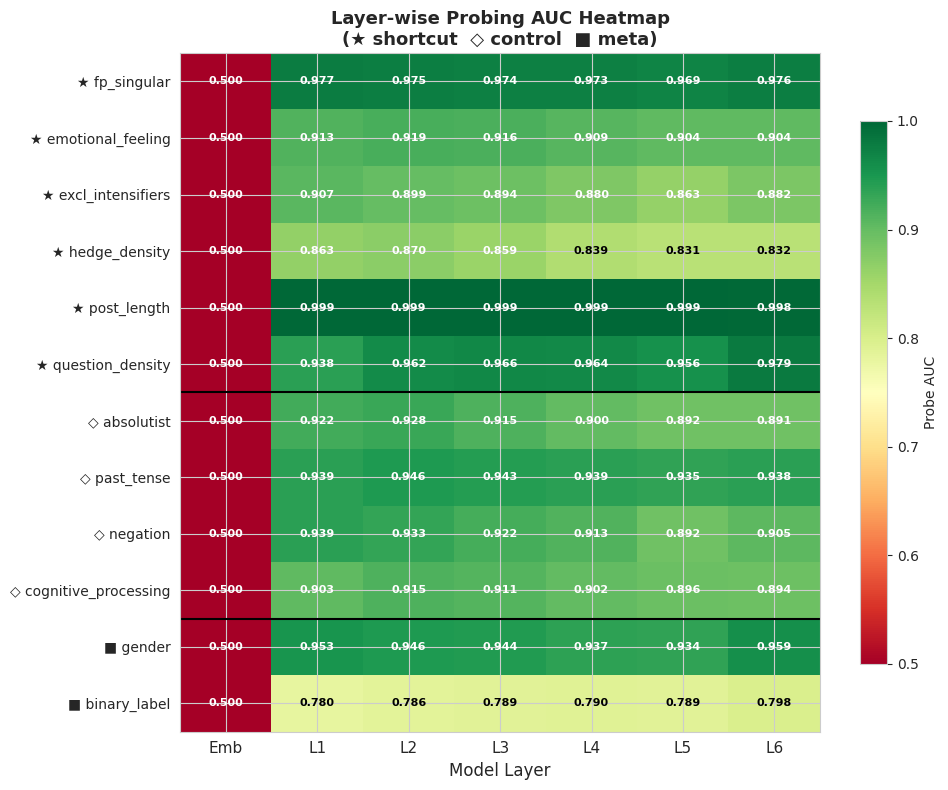

Saved → data/stage2/layerwise_heatmap.png
Saved → data/stage2/stage2_layerwise_probing.csv


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# HEATMAP — Compact layer × feature AUC matrix
# ══════════════════════════════════════════════════════════════════════════════
all_targets_ordered = SHORTCUT_FEATURES + CONTROL_FEATURES + ['gender', 'binary_label']
heatmap_data = layer_probe_df.pivot(index='target', columns='layer_name', values='AUC')
heatmap_data = heatmap_data.loc[all_targets_ordered, layer_names]

# Row labels with role annotation
row_labels = ([f'★ {f}' for f in SHORTCUT_FEATURES] +
              [f'◇ {f}' for f in CONTROL_FEATURES] +
              ['■ gender', '■ binary_label'])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)

ax.set_xticks(range(n_layers))
ax.set_xticklabels(layer_names, fontsize=11)
ax.set_yticks(range(len(all_targets_ordered)))
ax.set_yticklabels(row_labels, fontsize=10)
ax.set_xlabel('Model Layer', fontsize=12)
ax.set_title('Layer-wise Probing AUC Heatmap\n(★ shortcut  ◇ control  ■ meta)',
             fontsize=13, fontweight='bold')

# Annotate cells
for i in range(len(all_targets_ordered)):
    for j in range(n_layers):
        val = heatmap_data.values[i, j]
        color = 'white' if val > 0.85 or val < 0.55 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8,
                color=color, fontweight='bold')

# Add horizontal separators
ax.axhline(len(SHORTCUT_FEATURES) - 0.5, color='black', linewidth=1.5)
ax.axhline(len(SHORTCUT_FEATURES) + len(CONTROL_FEATURES) - 0.5,
           color='black', linewidth=1.5)

plt.colorbar(im, ax=ax, label='Probe AUC', shrink=0.8)
plt.tight_layout()
plt.savefig('data/stage2/layerwise_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/layerwise_heatmap.png")

# ── Save layer-wise results ──────────────────────────────────────────────────
layer_probe_df.to_csv('data/stage2/stage2_layerwise_probing.csv', index=False)
print("Saved → data/stage2/stage2_layerwise_probing.csv")

## 2B — SHAP Token Attribution

**Question:** When a logistic-regression model predicts `binary_label` using the 6 shortcut features, how much of its decision rests on each feature?

**Method:**
1. **Feature-level SHAP** — Fit a logistic regression on the 6 shortcut features → compute exact SHAP values → visualise per-feature importance.
2. **Token-level proxy** — For each shortcut feature, identify the tokens that *constitute* the feature (e.g., question marks for `question_density`, first-person pronouns for `fp_singular`). Measure what fraction of total feature value comes from each token type.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# SHAP — Feature-level attribution for the shortcut logistic model
# ══════════════════════════════════════════════════════════════════════════════
import shap

# Fit a logistic regression on the 6 shortcut features → binary_label
X_short = df[SHORTCUT_FEATURES].fillna(0).values.astype(float)
y_label = df['binary_label'].values.astype(int)

sc = StandardScaler()
X_short_scaled = sc.fit_transform(X_short)

clf_shap = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_shap.fit(X_short_scaled, y_label)

auc_short = roc_auc_score(y_label, clf_shap.predict_proba(X_short_scaled)[:, 1])
print(f"{len(SHORTCUT_FEATURES)}-shortcut logistic model AUC (train): {auc_short:.4f}")
print(f"Coefficients: {dict(zip(SHORTCUT_FEATURES, clf_shap.coef_[0].round(4)))}")

# ── Exact SHAP values (linear model → uses LinearExplainer) ──────────────────
explainer = shap.LinearExplainer(clf_shap, X_short_scaled, feature_names=SHORTCUT_FEATURES)
shap_values = explainer.shap_values(X_short_scaled)

print(f"\nSHAP value shape: {shap_values.shape}")
print(f"Mean |SHAP| per feature:")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
for feat, val in sorted(zip(SHORTCUT_FEATURES, mean_abs_shap), key=lambda x: -x[1]):
    print(f"  {feat:22s}: {val:.4f}")

6-shortcut logistic model AUC (train): 0.6796
Coefficients: {'fp_singular': np.float64(0.4443), 'emotional_feeling': np.float64(0.1974), 'excl_intensifiers': np.float64(0.0474), 'hedge_density': np.float64(0.0571), 'post_length': np.float64(0.2162), 'question_density': np.float64(-0.0752)}

SHAP value shape: (32200, 6)
Mean |SHAP| per feature:
  fp_singular           : 0.3767
  emotional_feeling     : 0.1254
  post_length           : 0.1098
  question_density      : 0.0487
  hedge_density         : 0.0429
  excl_intensifiers     : 0.0305


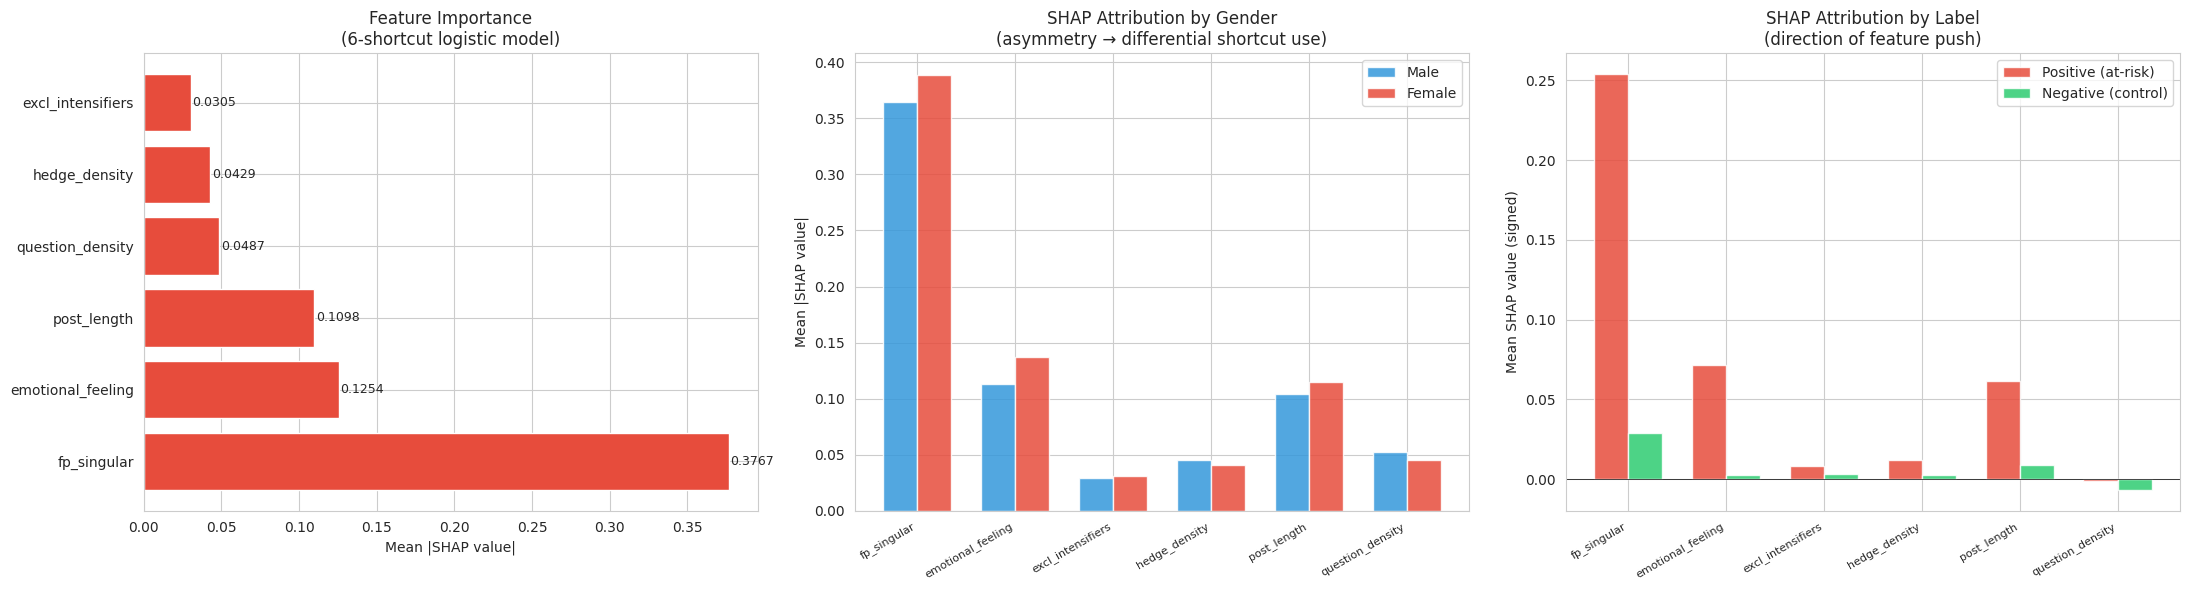

Saved → data/stage2/shap_shortcut_analysis.png


In [7]:
# ── SHAP visualisations ───────────────────────────────────────────────────────
n_short = len(SHORTCUT_FEATURES)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (A) SHAP bar plot — mean |SHAP| per feature
mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
palette_shap = {'Feminine-coded': '#e74c3c', 'Masculine-coded': '#3498db'}
bar_colors = [palette_shap.get(SHORTCUT_META[SHORTCUT_FEATURES[i]]['gender'], '#95a5a6') for i in order]
axes[0].barh(range(len(order)), mean_abs[order], color=bar_colors, edgecolor='white')
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([SHORTCUT_FEATURES[i] for i in order], fontsize=10)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Feature Importance\n({n_short}-shortcut logistic model)')
for i, idx in enumerate(order):
    axes[0].text(mean_abs[idx] + 0.001, i, f'{mean_abs[idx]:.4f}', va='center', fontsize=9)

# (B) SHAP by gender — are shortcut features used differently for male vs female?
shap_df = pd.DataFrame(shap_values, columns=SHORTCUT_FEATURES)
shap_df['gender'] = df[GENDER_COL].values

male_shap = shap_df[shap_df['gender'] == 'male'][SHORTCUT_FEATURES].abs().mean()
female_shap = shap_df[shap_df['gender'] == 'female'][SHORTCUT_FEATURES].abs().mean()

x = np.arange(n_short)
w = 0.35
axes[1].bar(x - w/2, male_shap.values, w, label='Male', color='#3498db', alpha=0.85)
axes[1].bar(x + w/2, female_shap.values, w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=8, rotation=30, ha='right')
axes[1].set_ylabel('Mean |SHAP value|')
axes[1].set_title('SHAP Attribution by Gender\n(asymmetry → differential shortcut use)')
axes[1].legend()

# (C) SHAP by label — positive vs negative
pos_shap = shap_df[df['binary_label'].values == 1][SHORTCUT_FEATURES].mean()
neg_shap = shap_df[df['binary_label'].values == 0][SHORTCUT_FEATURES].mean()

axes[2].bar(x - w/2, pos_shap.values, w, label='Positive (at-risk)', color='#e74c3c', alpha=0.85)
axes[2].bar(x + w/2, neg_shap.values, w, label='Negative (control)', color='#2ecc71', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(SHORTCUT_FEATURES, fontsize=8, rotation=30, ha='right')
axes[2].set_ylabel('Mean SHAP value (signed)')
axes[2].set_title('SHAP Attribution by Label\n(direction of feature push)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].legend()

plt.tight_layout()
plt.savefig('data/stage2/shap_shortcut_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/shap_shortcut_analysis.png")

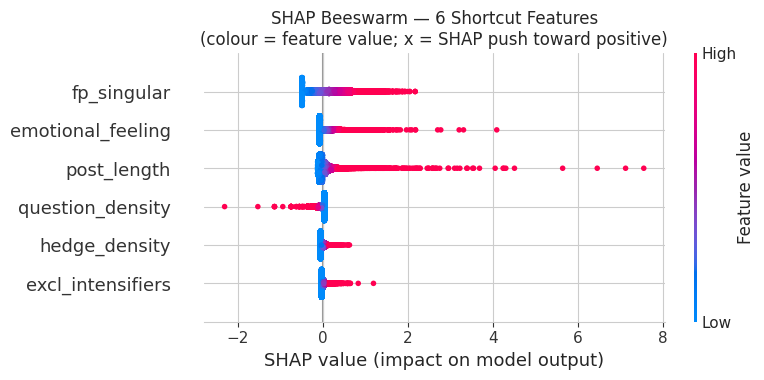

Saved → data/stage2/shap_beeswarm.png


In [8]:
# ── SHAP beeswarm — feature value × SHAP direction ───────────────────────────
# Shows whether HIGH or LOW values of each feature push toward positive label
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(shap_values), explainer.expected_value),
    data=X_short_scaled,
    feature_names=SHORTCUT_FEATURES,
)

fig, ax = plt.subplots(figsize=(12, 6))
shap.plots.beeswarm(shap_explanation, show=False, max_display=len(SHORTCUT_FEATURES))
plt.title(f'SHAP Beeswarm — {len(SHORTCUT_FEATURES)} Shortcut Features\n(colour = feature value; x = SHAP push toward positive)')
plt.tight_layout()
plt.savefig('data/stage2/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/shap_beeswarm.png")

## 2C — Feature Ablation: Quantifying Shortcut Reliance

**Question:** How much does the model rely on each shortcut feature? If we remove it, how much AUC is lost?

**Method:** Train an 18-feature logistic model (baseline), then ablate (zero-out) each shortcut feature one at a time and re-evaluate. Also test removing all 6 simultaneously. The AUC drop quantifies reliance.

Additionally: **gender-stratified ablation** — does removing a shortcut feature hurt performance more for one gender than the other? Asymmetric degradation = gender-biased shortcut.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ABLATION — Remove shortcut features, measure AUC drop
# ══════════════════════════════════════════════════════════════════════════════
ALL_18_FEATURES = [
    'hedge_density', 'fp_singular', 'fp_plural', 'emotional_feeling',
    'social_relational', 'certainty', 'negative_emotion', 'swear_words',
    'excl_intensifiers', 'question_density', 'post_length', 'apology_selfblame',
    'anger', 'body_health',
    'absolutist', 'past_tense', 'negation', 'cognitive_processing',
]

X_all = df[ALL_18_FEATURES].fillna(0).values.astype(float)
y_all = df['binary_label'].values.astype(int)

sc18 = StandardScaler()
X_all_scaled = sc18.fit_transform(X_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline — all 18 features
clf_base = LogisticRegression(max_iter=1000, random_state=42)
base_aucs = cross_val_score(clf_base, X_all_scaled, y_all, cv=cv, scoring='roc_auc')
baseline_auc = base_aucs.mean()
print(f"Baseline (18 features): AUC = {baseline_auc:.4f} ± {base_aucs.std():.4f}")

# Single-feature ablation
ablation_results = []
for feat in SHORTCUT_FEATURES:
    feat_idx = ALL_18_FEATURES.index(feat)
    X_abl = X_all_scaled.copy()
    X_abl[:, feat_idx] = 0  # zero-out the feature

    clf_abl = LogisticRegression(max_iter=1000, random_state=42)
    abl_aucs = cross_val_score(clf_abl, X_abl, y_all, cv=cv, scoring='roc_auc')

    drop = baseline_auc - abl_aucs.mean()
    ablation_results.append({
        'ablated': feat,
        'AUC_after': abl_aucs.mean(),
        'AUC_std': abl_aucs.std(),
        'AUC_drop': drop,
        'drop_pct': drop / baseline_auc * 100,
    })
    print(f"  Ablate {feat:22s}: AUC = {abl_aucs.mean():.4f}  (Δ = {drop:+.4f}, {drop/baseline_auc*100:+.2f}%)")

# All 6 shortcut features ablated simultaneously
feat_idxs = [ALL_18_FEATURES.index(f) for f in SHORTCUT_FEATURES]
X_abl_all = X_all_scaled.copy()
X_abl_all[:, feat_idxs] = 0
clf_abl_all = LogisticRegression(max_iter=1000, random_state=42)
abl_all_aucs = cross_val_score(clf_abl_all, X_abl_all, y_all, cv=cv, scoring='roc_auc')
drop_all = baseline_auc - abl_all_aucs.mean()
print(f"\n  Ablate ALL {len(SHORTCUT_FEATURES)} shortcuts: AUC = {abl_all_aucs.mean():.4f}  "
      f"(Δ = {drop_all:+.4f}, {drop_all/baseline_auc*100:+.2f}%)")

ablation_df = pd.DataFrame(ablation_results)
ablation_df

Baseline (18 features): AUC = 0.7129 ± 0.0054
  Ablate fp_singular           : AUC = 0.6990  (Δ = +0.0139, +1.95%)
  Ablate emotional_feeling     : AUC = 0.7109  (Δ = +0.0021, +0.29%)
  Ablate excl_intensifiers     : AUC = 0.7122  (Δ = +0.0007, +0.10%)
  Ablate hedge_density         : AUC = 0.7126  (Δ = +0.0003, +0.05%)
  Ablate post_length           : AUC = 0.7074  (Δ = +0.0055, +0.77%)
  Ablate question_density      : AUC = 0.7123  (Δ = +0.0006, +0.09%)

  Ablate ALL 6 shortcuts: AUC = 0.6839  (Δ = +0.0291, +4.08%)


,ablated,AUC_after,AUC_std,AUC_drop,drop_pct
0,fp_singular,0.699016,0.006089,0.013925,1.953189
1,emotional_feeling,0.710867,0.005287,0.002074,0.290898
2,excl_intensifiers,0.712234,0.005095,0.000707,0.099174
3,hedge_density,0.712595,0.005448,0.000347,0.048602
4,post_length,0.707443,0.006265,0.005498,0.771219
5,question_density,0.712314,0.004900,0.000627,0.087997


Gender-stratified ablation (AUC drop):
gender             female    male  asymmetry
ablated                                     
emotional_feeling  0.0022  0.0000     0.0022
excl_intensifiers  0.0000 -0.0008     0.0008
fp_singular        0.0109  0.0041     0.0068
hedge_density      0.0004  0.0010     0.0006
post_length        0.0036  0.0078     0.0042
question_density   0.0007  0.0012     0.0005


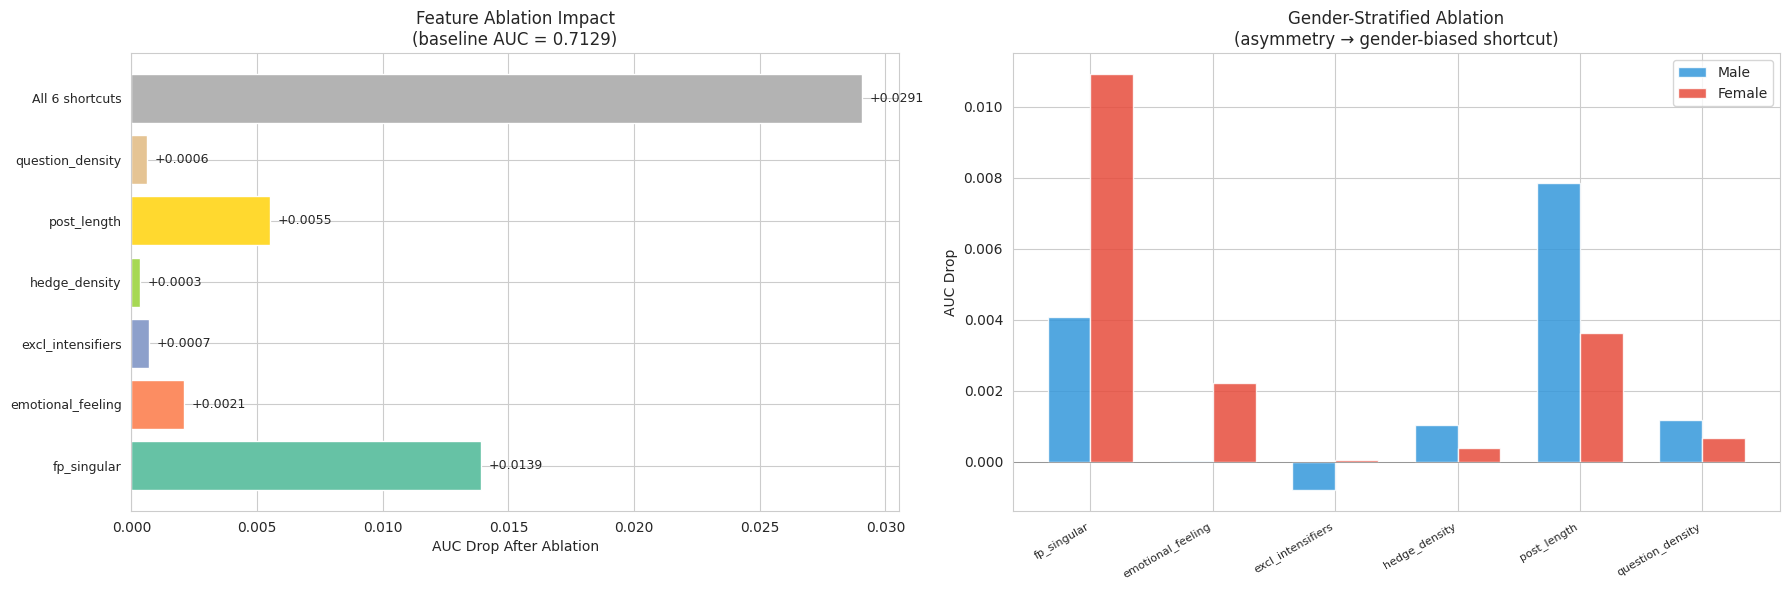

Saved → data/stage2/ablation_analysis.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# GENDER-STRATIFIED ABLATION — Does shortcut removal hurt one gender more?
# ══════════════════════════════════════════════════════════════════════════════
# Train on FULL data, evaluate separately on male & female subsets.
# Asymmetric AUC drop → shortcut is gender-biased.

clf_full = LogisticRegression(max_iter=1000, random_state=42)
clf_full.fit(X_all_scaled, y_all)

# All rows are male/female in this dataset
genders = df[GENDER_COL].values

strat_results = []

for gender in ['male', 'female']:
    g_mask = genders == gender
    X_g = X_all_scaled[g_mask]
    y_g = y_all[g_mask]

    if len(np.unique(y_g)) < 2:
        continue

    # Baseline AUC for this gender
    base_auc_g = roc_auc_score(y_g, clf_full.predict_proba(X_g)[:, 1])

    for feat in SHORTCUT_FEATURES:
        feat_idx = ALL_18_FEATURES.index(feat)
        X_g_abl = X_g.copy()
        X_g_abl[:, feat_idx] = 0
        abl_auc_g = roc_auc_score(y_g, clf_full.predict_proba(X_g_abl)[:, 1])
        drop_g = base_auc_g - abl_auc_g

        strat_results.append({
            'gender': gender,
            'ablated': feat,
            'n_posts': g_mask.sum(),
            'baseline_AUC': base_auc_g,
            'ablated_AUC': abl_auc_g,
            'AUC_drop': drop_g,
            'drop_pct': drop_g / base_auc_g * 100,
        })

strat_df = pd.DataFrame(strat_results)

# Pivot for clear comparison
print("Gender-stratified ablation (AUC drop):")
pivot = strat_df.pivot(index='ablated', columns='gender', values='AUC_drop')
pivot['asymmetry'] = (pivot['male'] - pivot['female']).abs()
print(pivot.round(4).to_string())

# ── Visualization ─────────────────────────────────────────────────────────────
n_short = len(SHORTCUT_FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (A) Ablation AUC drops — overall
abl_labels = list(ablation_df['ablated']) + [f'All {n_short} shortcuts']
abl_drops  = list(ablation_df['AUC_drop']) + [drop_all]
cmap = plt.cm.Set2(np.linspace(0, 1, n_short + 1))
colors_abl = [cmap[i] for i in range(len(abl_labels))]

axes[0].barh(range(len(abl_labels)), abl_drops, color=colors_abl, edgecolor='white')
axes[0].set_yticks(range(len(abl_labels)))
axes[0].set_yticklabels(abl_labels, fontsize=9)
axes[0].set_xlabel('AUC Drop After Ablation')
axes[0].set_title(f'Feature Ablation Impact\n(baseline AUC = {baseline_auc:.4f})')
axes[0].axvline(0, color='grey', linewidth=0.5)
for i, d in enumerate(abl_drops):
    axes[0].text(max(d, 0) + 0.0003, i, f'{d:+.4f}', va='center', fontsize=9)

# (B) Gender-stratified ablation
x = np.arange(n_short)
w = 0.35
male_drops = strat_df[strat_df['gender']=='male'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
female_drops = strat_df[strat_df['gender']=='female'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values

axes[1].bar(x - w/2, male_drops, w, label='Male', color='#3498db', alpha=0.85)
axes[1].bar(x + w/2, female_drops, w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=8, rotation=30, ha='right')
axes[1].set_ylabel('AUC Drop')
axes[1].set_title('Gender-Stratified Ablation\n(asymmetry → gender-biased shortcut)')
axes[1].legend()
axes[1].axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.savefig('data/stage2/ablation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/ablation_analysis.png")

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2 SUMMARY — Save all results
# ══════════════════════════════════════════════════════════════════════════════
probe_df.to_csv('data/stage2/stage2_probing_results.csv', index=False)
ablation_df.to_csv('data/stage2/stage2_ablation_results.csv', index=False)
strat_df.to_csv('data/stage2/stage2_gender_stratified_ablation.csv', index=False)

# Save SHAP values for downstream use
np.save('data/stage2/stage2_shap_values.npy', shap_values)

print("=" * 60)
print("STAGE 2 SUMMARY — SHORTCUT AUDITING (18-feature design)")
print("=" * 60)

print(f"\n(A) PROBING — Does frozen DistilRoBERTa [CLS] encode shortcuts & controls?")
for _, row in probe_df.iterrows():
    encoded = "YES" if row['probe_AUC_median_split'] > 0.55 else "weak/NO"
    tag = "★SHORTCUT" if row['role'] == 'shortcut' else "  control"
    print(f"  [{tag}] {row['feature']:22s}  AUC={row['probe_AUC_median_split']:.3f}  R²={row['probe_R2']:.4f}  → {encoded}")
print(f"  {'gender (m/f)':33s}  AUC={aucs_g.mean():.3f}")
print(f"  {'binary_label':33s}  AUC={aucs_l.mean():.3f}")

print(f"\n(B) SHAP — Feature attribution ({len(SHORTCUT_FEATURES)}-shortcut logistic model):")
for feat, val in sorted(zip(SHORTCUT_FEATURES, mean_abs_shap), key=lambda x: -x[1]):
    pct = val / mean_abs_shap.sum() * 100
    print(f"  {feat:22s}  mean|SHAP|={val:.4f}  ({pct:.1f}% of total)")

print(f"\n(C) ABLATION — AUC impact of removing shortcuts:")
print(f"  Baseline (18 features): AUC = {baseline_auc:.4f}")
for _, row in ablation_df.iterrows():
    print(f"  Remove {row['ablated']:22s}: AUC = {row['AUC_after']:.4f}  (Δ = {row['AUC_drop']:+.4f})")
print(f"  Remove ALL {len(SHORTCUT_FEATURES)}:               AUC = {abl_all_aucs.mean():.4f}  (Δ = {drop_all:+.4f})")

print(f"\n(D) GENDER-STRATIFIED ABLATION — Asymmetric impact:")
for feat in SHORTCUT_FEATURES:
    m_drop = strat_df[(strat_df['ablated']==feat) & (strat_df['gender']=='male')]['AUC_drop'].values[0]
    f_drop = strat_df[(strat_df['ablated']==feat) & (strat_df['gender']=='female')]['AUC_drop'].values[0]
    asym = abs(m_drop - f_drop)
    bias_dir = "→ male" if m_drop > f_drop else "→ female"
    print(f"  {feat:22s}  male Δ={m_drop:+.4f}  female Δ={f_drop:+.4f}  asymmetry={asym:.4f} {bias_dir}")

print(f"\nSaved:")
for f in ['stage2_probing_results.csv', 'stage2_ablation_results.csv',
          'stage2_gender_stratified_ablation.csv', 'stage2_shap_values.npy',
          'probing_results.png', 'shap_shortcut_analysis.png',
          'shap_beeswarm.png', 'ablation_analysis.png']:
    print(f"  → data/stage2/{f}")

STAGE 2 SUMMARY — SHORTCUT AUDITING (18-feature design)

(A) PROBING — Does frozen DistilRoBERTa [CLS] encode shortcuts & controls?
  [★SHORTCUT] fp_singular             AUC=0.976  R²=0.8555  → YES
  [★SHORTCUT] emotional_feeling       AUC=0.904  R²=0.3778  → YES
  [★SHORTCUT] excl_intensifiers       AUC=0.882  R²=0.5957  → YES
  [★SHORTCUT] hedge_density           AUC=0.832  R²=0.4060  → YES
  [★SHORTCUT] post_length             AUC=0.998  R²=0.4412  → YES
  [★SHORTCUT] question_density        AUC=0.979  R²=0.7765  → YES
  [  control] absolutist              AUC=0.891  R²=0.3032  → YES
  [  control] past_tense              AUC=0.938  R²=0.6664  → YES
  [  control] negation                AUC=0.905  R²=0.5404  → YES
  [  control] cognitive_processing    AUC=0.894  R²=0.2743  → YES
  gender (m/f)                       AUC=0.959
  binary_label                       AUC=0.798

(B) SHAP — Feature attribution (6-shortcut logistic model):
  fp_singular             mean|SHAP|=0.3767  (51.3% o

## Stage 2 Results Interpretation

### Why [CLS] from unfinetuned DistilRoBERTa?
This is a diagnostic probe — not the model you'd deploy. The logic is:

1. **Pre-training encodes linguistic style.** A language model trained on generic web text learns representations that capture stylistic features (pronoun use, emotionality, hedging, etc.) as a byproduct of language modeling.
2. **If shortcuts are already recoverable before fine-tuning**, the model has a "head start" on exploiting them. When you later fine-tune on mental health classification, the model can cheaply leverage these pre-existing gender-correlated features instead of learning deeper clinical signal.
3. **This establishes a ceiling of concern.** If the frozen model couldn't recover shortcuts, there'd be less worry about fine-tuning amplifying them.

### What the control features tell us
The 4 control features (absolutist, past_tense, negation, cognitive_processing) serve as a baseline:

- **Validated controls** (negation, cognitive_processing): should show lower probing AUC and smaller ablation impact — they carry clinical signal without strong gender mediation.
- **Failed controls** (absolutist, past_tense): unexpectedly flagged by MI — if they show high probing AUC, this confirms they are gender-confounded in this corpus despite clinical literature support.

The shortcut vs control comparison in probing/ablation panels provides a built-in sanity check for the MI decomposition.